# Structured GP: Kronecker and Low-Rank

This notebook shows where gaussx shines: exploiting structure in
kernel matrices for Gaussian process inference.

We cover two common patterns:

1. **Kronecker structure** — GP on a grid (e.g. spatial data on a regular mesh)
2. **Low-rank + diagonal** — sparse GP with inducing points (Nystrom approximation)

The two most common forms of kernel structure in GP models are
(1) Kronecker products from separable kernels on grids, and
(2) low-rank approximations from inducing point methods. Both reduce
the $O(N^3)$ cost of dense GP inference. gaussx supports both through
its operator type system, dispatching to the optimal algorithm
automatically.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

---
## Part 1: Kronecker GP on a grid

When input data lies on a grid, the kernel matrix factorizes as
a Kronecker product: $K = K_1 \otimes K_2$. This turns $O(N^3)$
operations into $O(n_1^3 + n_2^3)$ where $N = n_1 n_2$.

For a separable kernel on 2D inputs the factorization is:

$$k((x_1,y_1),(x_2,y_2)) = k_x(x_1,x_2) \cdot k_y(y_1,y_2)$$

This includes products of any 1D stationary kernels (e.g. RBF, Matern).
See Saatci (2012) for a comprehensive treatment of Kronecker methods
in GP models.

### Setup: 2D grid data

In [2]:
def rbf_kernel_1d(x, lengthscale, variance):
    """1D RBF kernel matrix."""
    sq_dist = (x[:, None] - x[None, :]) ** 2
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


# Grid dimensions
n1, n2 = 10, 12
N = n1 * n2  # Total points = 120

x1 = jnp.linspace(0, 5, n1)
x2 = jnp.linspace(0, 5, n2)

print(f"Grid: {n1} x {n2} = {N} points")
print(f"Dense kernel would be {N} x {N} = {N**2:,} entries")
print(f"Kronecker stores {n1}x{n1} + {n2}x{n2} = {n1**2 + n2**2} entries")

Grid: 10 x 12 = 120 points
Dense kernel would be 120 x 120 = 14,400 entries
Kronecker stores 10x10 + 12x12 = 244 entries


### Build the Kronecker kernel

In [3]:
# Per-dimension kernel matrices (lengthscale ~ grid spacing for good conditioning)
K1 = rbf_kernel_1d(x1, lengthscale=1.0, variance=1.0)
K2 = rbf_kernel_1d(x2, lengthscale=1.0, variance=1.0)

# Wrap as PSD lineax operators
K1_op = lx.MatrixLinearOperator(K1, lx.positive_semidefinite_tag)
K2_op = lx.MatrixLinearOperator(K2, lx.positive_semidefinite_tag)

# Kronecker product: K = K1 kron K2
K_kron = gaussx.Kronecker(K1_op, K2_op)

# Add noise: (K1 kron K2) + sigma^2 I
# For now, materialize noise addition — a full structured version
# would use a LowRankUpdate or custom operator.
noise_var = 0.01

print(f"Kronecker operator size: {K_kron.in_size()}")

Kronecker operator size: 120


### Kronecker logdet

The key identity: $\log|K_1 \otimes K_2| = n_2 \log|K_1| + n_1 \log|K_2|$

gaussx computes this automatically — no need to form the $N \times N$ matrix.

In [4]:
# Structured logdet: O(n1^3 + n2^3)
ld_structured = gaussx.logdet(K_kron)
print(f"logdet (structured): {ld_structured:.6f}")

# Verify against dense: O(N^3)
ld_dense = jnp.linalg.slogdet(K_kron.as_matrix())[1]
print(f"logdet (dense):      {ld_dense:.6f}")
print(f"Match: {jnp.allclose(ld_structured, ld_dense)}")

logdet (structured): -805.280930


logdet (dense):      -805.280929
Match: True


### Kronecker solve and Cholesky

Solve and Cholesky also decompose per-factor.

In [5]:
# Generate observations on the grid
key = jax.random.PRNGKey(0)
y = jax.random.normal(key, (N,))

# Structured solve of K_kron @ alpha = y
alpha = gaussx.solve(K_kron, y)
print(f"solve residual: {jnp.max(jnp.abs(K_kron.mv(alpha) - y)):.2e}")

# Structured Cholesky: returns Kronecker(chol(K1), chol(K2))
L = gaussx.cholesky(K_kron)
print(f"cholesky type: {type(L).__name__}")
print(f"L factors: {[type(f).__name__ for f in L.operators]}")

# Verify: L L^T = K
recon_err = jnp.max(jnp.abs(L.as_matrix() @ L.as_matrix().T - K_kron.as_matrix()))
print(f"Cholesky reconstruction error: {recon_err:.2e}")

solve residual: 2.27e-07
cholesky type: Kronecker
L factors: ['MatrixLinearOperator', 'MatrixLinearOperator']


Cholesky reconstruction error: 4.44e-16


---
## Part 2: Low-rank GP (Nystrom / inducing points)

For non-grid data, a common approximation is $K \approx K_{nm} K_{mm}^{-1} K_{mn}$.
The resulting covariance is $\text{diag}(\sigma^2) + U U^\top$ — a low-rank update.

The Woodbury identity gives an efficient solve:

$$(\sigma^2 I + UU^\top)^{-1} = \sigma^{-2} I
  - \sigma^{-2} U (I + \sigma^{-2} U^\top U)^{-1} U^\top \sigma^{-2}$$

and the matrix determinant lemma gives an efficient logdet:

$$\log|\sigma^2 I + UU^\top| = N \log \sigma^2 + \log|I + \sigma^{-2} U^\top U|$$

Both reduce the cost from $O(N^3)$ to $O(NM^2 + M^3)$.

### Setup: random 1D data with inducing points

In [6]:
n_data = 200
n_inducing = 15

key = jax.random.PRNGKey(7)
k1, k2 = jax.random.split(key)

x_data = jax.random.uniform(k1, (n_data,), minval=-3.0, maxval=3.0)
x_inducing = jnp.linspace(-2.5, 2.5, n_inducing)

print(f"Data points: {n_data}")
print(f"Inducing points: {n_inducing}")
print(f"Dense kernel: {n_data}x{n_data} = {n_data**2:,} entries")
print(
    f"Low-rank: {n_data}x{n_inducing} + {n_inducing}x{n_inducing} "
    f"= {n_data * n_inducing + n_inducing**2:,} entries"
)

Data points: 200
Inducing points: 15
Dense kernel: 200x200 = 40,000 entries
Low-rank: 200x15 + 15x15 = 3,225 entries


### Build the low-rank approximation

In [7]:
ls, var = 1.0, 1.5
noise = 0.1


def rbf_kernel_2d(x1, x2, ls, var):
    sq_dist = (x1[:, None] - x2[None, :]) ** 2
    return var * jnp.exp(-0.5 * sq_dist / ls**2)


# K_nm: data-to-inducing kernel
K_nm = rbf_kernel_2d(x_data, x_inducing, ls, var)

# K_mm: inducing-to-inducing kernel
K_mm = rbf_kernel_2d(x_inducing, x_inducing, ls, var)

# Nystrom factor: U = K_nm @ chol(K_mm)^{-T} gives K approx U U^T
L_mm = jnp.linalg.cholesky(K_mm + 1e-6 * jnp.eye(n_inducing))
U = jax.scipy.linalg.solve_triangular(L_mm, K_nm.T, lower=True).T

print(f"U shape: {U.shape}")  # (200, 15)

U shape: (200, 15)


### Construct gaussx LowRankUpdate operator

$\Sigma = \sigma^2 I + U U^\top$

In [8]:
diag_noise = noise * jnp.ones(n_data)
sigma = gaussx.low_rank_plus_diag(diag_noise, U)

print(f"LowRankUpdate rank: {sigma.rank}")
print(f"Operator size: {sigma.in_size()}")
print(f"gaussx.is_low_rank: {gaussx.is_low_rank(sigma)}")

LowRankUpdate rank: 15
Operator size: 200
gaussx.is_low_rank: True


### Solve and logdet via Woodbury

gaussx automatically uses the Woodbury identity for solve
and the matrix determinant lemma for logdet — O(nk^2 + k^3)
instead of O(n^3).

In [9]:
# Generate observations
y_data = jnp.sin(2 * x_data) + noise * jax.random.normal(k2, (n_data,))

# Woodbury solve: (sigma^2 I + U U^T)^{-1} y
alpha = gaussx.solve(sigma, y_data)
print(f"solve residual: {jnp.max(jnp.abs(sigma.mv(alpha) - y_data)):.2e}")

# Matrix determinant lemma logdet
ld = gaussx.logdet(sigma)
ld_dense = jnp.linalg.slogdet(sigma.as_matrix())[1]
print(f"logdet (Woodbury):  {ld:.6f}")
print(f"logdet (dense):     {ld_dense:.6f}")
print(f"Match: {jnp.allclose(ld, ld_dense, rtol=1e-4)}")

solve residual: 4.56e-13


logdet (Woodbury):  -421.679302
logdet (dense):     -421.679302
Match: True


### Log-marginal likelihood

In [10]:
def sparse_gp_lml(y, sigma_op):
    """Sparse GP log-marginal likelihood."""
    alpha = gaussx.solve(sigma_op, y)
    data_fit = -0.5 * jnp.dot(y, alpha)
    complexity = -0.5 * gaussx.logdet(sigma_op)
    constant = -0.5 * len(y) * jnp.log(2 * jnp.pi)
    return data_fit + complexity + constant


lml = sparse_gp_lml(y_data, sigma)
print(f"Sparse GP LML: {lml:.4f}")

Sparse GP LML: 12.4216


### Visualize the sparse GP fit

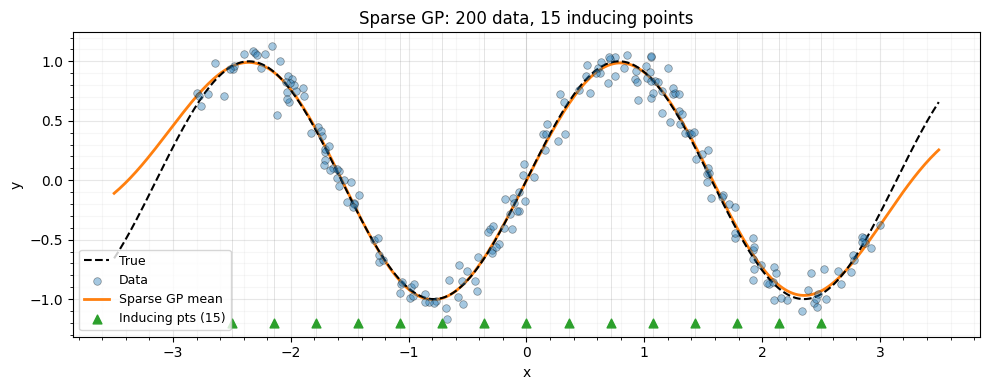

In [11]:
# Predict on a test grid using the sparse approximation
x_plot = jnp.linspace(-3.5, 3.5, 300)
K_star_m = rbf_kernel_2d(x_plot, x_inducing, ls, var)
L_mm_op = lx.MatrixLinearOperator(
    K_mm + 1e-6 * jnp.eye(n_inducing), lx.positive_semidefinite_tag
)
# Nystrom prediction weights
alpha_sparse = gaussx.solve(sigma, y_data)
# Project through inducing points
w = U.T @ alpha_sparse  # (k,)
y_plot = K_star_m @ jnp.linalg.solve(
    K_mm + 1e-6 * jnp.eye(n_inducing), K_nm.T @ alpha_sparse
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_plot, jnp.sin(2 * x_plot), "k--", lw=1.5, label="True", zorder=4)
ax.scatter(
    x_data,
    y_data,
    s=30,
    c="C0",
    alpha=0.4,
    edgecolors="k",
    linewidths=0.5,
    label="Data",
    zorder=5,
)
ax.plot(x_plot, y_plot, "C1-", lw=2, label="Sparse GP mean", zorder=3)
ax.axvline(x_inducing[0], color="gray", lw=0.5, alpha=0.3)
for xi in x_inducing[1:]:
    ax.axvline(xi, color="gray", lw=0.5, alpha=0.3)
ax.scatter(
    x_inducing,
    jnp.zeros_like(x_inducing) - 1.2,
    marker="^",
    s=40,
    c="C2",
    zorder=5,
    label=f"Inducing pts ({n_inducing})",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Sparse GP: {n_data} data, {n_inducing} inducing points")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Summary

| Structure | When to use | Solve cost | Logdet cost |
|-----------|------------|------------|-------------|
| `Kronecker(K1, K2)` | Grid data | O(n1^3 + n2^3) | O(n1^3 + n2^3) |
| `low_rank_plus_diag` | Inducing points | O(nk^2 + k^3) | O(nk^2 + k^3) |
| Dense | Unstructured | O(n^3) | O(n^3) |

gaussx dispatches to the right algorithm automatically based
on the operator type — write the math once, get efficient
computation for free.

## References

- Quinonero-Candela, J. & Rasmussen, C. E. (2005). A unifying view of sparse
  approximate Gaussian process regression. *JMLR*, 6, 1939--1959.
- Saatci, Y. (2012). *Scalable Inference for Structured Gaussian Process
  Models*. PhD thesis, University of Cambridge.
- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes for
  Machine Learning*. MIT Press.